# A Comprehensive Introduction of Medusa
Sept, 2023 | 45 min | Yuhong Li

In [2]:
import os
import sys
sys.path.append("../") # 否则找不到medusa/model/medusa_model.py

#os.environ["CUDA_VISIBLE_DEVICES"] = "0" # define GPU id, remove if you want to use all GPUs available
import torch
from contextlib import contextmanager
import numpy as np
from medusa.model.medusa_model import MedusaModel
from medusa.model.kv_cache import *
from medusa.model.utils import *
from medusa.model.medusa_choices import *
from copy import deepcopy
import matplotlib.pyplot as plt

## How LLM inference?

In this section, we will illustrate LLM inference with KV cache mechanism.

The Key-Value (KV) cache mechanism serves as a rapid-access storage during inference. By retaining the model's intermediate KV features from previous inferences in this cache, computation time can be substantially reduced.


Consider an example where the incoming input token has a shape of `[1, 1]`, denoting a batch_size of 1 and a sequence_length of 1. If the model has prior intermediate KV features stored in the cache, the inference will proceed as follows:


1. **Embedding Mapping**: The model transforms the input token into an embedding vector, resulting in a shape of `[1, 1, hidden_size]`.

2. **Forward through FFN**: This embedded vector is then passed through the Feed Forward Network (FFN) module, yielding an output with the same shape: `[1, 1, hidden_size]`.

3. **Attention Mechanism**: 

    * The query vector for the current token is reshaped and transformed from `[1, 1, hidden_size]` to `[1, 1, num_heads, head_dim]` to `[1, num_heads, 1, head_dim]`.
    * The cached intermediate KV vectors from previous inferences have the shape `[1, num_heads, prev_kv_seq_len, head_dim]`.
    * Current KV vectors are concatenated with these cached KV vectors, resulting in a new shape of `[1, num_heads, prev_kv_seq_len + 1, head_dim]`. 注意：这里是先concatenate, 再进行attention,因为query需要对自己也进行attention
    * The QK matrix is computed as the dot product of the query vector and the concatenated KV vectors.
    * Hence, the QK matrix's shape is `[1, num_heads, 1, head_dim] x [1, num_heads, head_dim, prev_kv_seq_len + 1]` -> `[1, num_heads, 1, prev_kv_seq_len + 1]`.
    * The (QK)V matrix's shape is `[1, num_heads, 1, prev_kv_seq_len + 1] x [1, num_heads, prev_kv_seq_len + 1, head_dim]` -> `[1, num_heads, 1, head_dim]`.
    * The output is transformed and reshaped to `[1, 1, hidden_size]`.

Without the KV cache mechanism, the inference will proceed the **whole sequence** each time, resulting in significantly larger QK matrix and slower FFN computation.

If you want to know more about KV cache, please refer to the awesome [blog](https://www.dipkumar.dev/becoming-the-unbeatable/posts/gpt-kvcache/).

Let's try an example with KV cache inference:

In [3]:
# model_name = 'FasterDecoding/medusa-vicuna-7b-v1.3'
# model = MedusaModel.from_pretrained(
#     model_name,
#     medusa_num_heads = 4,
#     torch_dtype=torch.float16,
#     low_cpu_mem_usage=True,
#     device_map="auto"
# )
base_model_path = "/home/hkx/data/work/hf_data_and_model/models/MoZhang96/TinyStories-LLaMA2-20M-256h-4l-GQA"
#medusa_model_path = "/home/hkx/data/work/open/Medusa/llama_medusa_output_medusa_mlp_TinyStories-LLaMA2-20M-256h-4l-GQA_medusa_2_lr_0.001_layers_1" 
medusa_model_path = "/home/hkx/data/work/open/Medusa/llama_medusa_output2_medusa_mlp_TinyStories-LLaMA2-20M-256h-4l-GQA_medusa_2_lr_0.001_layers_1" 
# medusa_config: MedusaConfig = MedusaConfig.from_pretrained(medusa_model_path)
# medusa_config.base_model_name_or_path = base_model_path
# #base_model_config = AutoConfig.from_pretrained(config.base_model_name_or_path)
# #config.model_type = base_model_config.model_type
# base_model = LlamaForCausalLM.from_pretrained(pretrained_model_name_or_path=base_model_path)
# tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=base_model_path)

# ---------------
#args = dict(medusa_num_heads=medusa_config.medusa_num_heads, medusa_num_layers=medusa_config.medusa_num_layers)
model = MedusaModel.from_pretrained(base_model_path=base_model_path, medusa_head_path=medusa_model_path)
import copy
# 注意：此处为了debug, 临时增加了medusa_head
with torch.inference_mode():
    add_heads_num = 3
    model.medusa_head.extend([copy.deepcopy(model.medusa_head[0]) for _ in range(add_heads_num)])
    model.medusa_num_heads += add_heads_num
print(f"{model=}")

tokenizer = model.get_tokenizer()

medusa_choices = mc_sim_7b_63


LlamaForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


inited model:medusa_model=MedusaModel(
  (base_model): LlamaForCausalLM(
    (model): LlamaModel(
      (embed_tokens): Embedding(32000, 256)
      (layers): ModuleList(
        (0-3): 4 x LlamaDecoderLayer(
          (self_attn): LlamaAttention(
            (q_proj): Linear(in_features=256, out_features=256, bias=False)
            (k_proj): Linear(in_features=256, out_features=128, bias=False)
            (v_proj): Linear(in_features=256, out_features=128, bias=False)
            (o_proj): Linear(in_features=256, out_features=256, bias=False)
            (rotary_emb): LlamaRotaryEmbedding()
          )
          (mlp): LlamaMLP(
            (gate_proj): Linear(in_features=256, out_features=768, bias=False)
            (up_proj): Linear(in_features=256, out_features=768, bias=False)
            (down_proj): Linear(in_features=768, out_features=256, bias=False)
            (act_fn): SiLU()
          )
          (input_layernorm): LlamaRMSNorm()
          (post_attention_layernorm): Lla

### Initialize the kv_cache

In [4]:
# 初始化kv cache
# past_key_values: [ [KvCache(key), KvCache(value)], [KvCache(key), KvCache(value)], ...], 有 num_hidden_layers 个 key-value kvcache对象
# 每个KVCache.data的shape为 [batch_size, head_num, max_seq_len, head_dim]
# past_key_values_data: [num_hidden_layers * 2, batch_size, head_num, max_seq_len=2048, head_dim]
# current_legth_data: [num_hidden_layers * 2], 奇数和偶数分别对应key和value的长度
past_key_values, past_key_values_data, current_length_data = initialize_past_key_values(model.base_model)
model.past_key_values = past_key_values
model.past_key_values_data = past_key_values_data
model.current_length_data = current_length_data
print(f"{model.base_model.config.max_position_embeddings=}") # 2048
print(f"第0层的key的cache分配的内存张量大小:{past_key_values[0][0].data.shape=}") # (1, 8, 2048, 16)
print(f"第0层的key的cache实际有效数据的张量大小:{past_key_values[0][0].shape=}") # (1, 8, 0, 16)

past_key_values_data shape: torch.Size([8, 1, 8, 2048, 16])
model.base_model.config.max_position_embeddings=2048
第0层的key的cache分配的内存张量大小:past_key_values[0][0].data.shape=torch.Size([1, 8, 2048, 16])
第0层的key的cache实际有效数据的张量大小:past_key_values[0][0].shape=(1, 8, 0, 16)


### Set the prompt

The prompt is as follow:

A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: Hi, could you share a tale about a charming llama that grows Medusa-like hair and starts its own coffee shop? ASSISTANT:

In [5]:
# 清空当前kvcache缓存
# current_length_data: [num_hidden_layers * 2]
model.current_length_data.zero_() # this is for rerun

prompt = "A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: Hi, could you share a tale about a charming llama that grows Medusa-like hair and starts its own coffee shop? ASSISTANT:"
print(prompt)
input_ids = tokenizer([prompt]).input_ids
input_len = len(input_ids[0])
print('Input token length:', len(input_ids[0]))
# 打印第0层的KV cache 中的key, value的shape, shape: [batch_size, head_num, cache_seq_len, head_dim]
print('Init KV cache shape for attention modules:', model.past_key_values[0][0].shape, model.past_key_values[0][1].shape)
print(f'当前各层的缓存长度:{model.current_length_data}  layer_number:{model.current_length_data.shape[0]}')
"""
Input token length: 66
Init KV cache shape for attention modules: (1, 8, 0, 16) (1, 8, 0, 16) # 可以看到，初始化时，所有层的缓存长度都是0
当前各层的缓存长度:tensor([0, 0, 0, 0, 0, 0, 0, 0])  layer_number:8
"""

A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: Hi, could you share a tale about a charming llama that grows Medusa-like hair and starts its own coffee shop? ASSISTANT:
Input token length: 66
Init KV cache shape for attention modules: (1, 8, 0, 16) (1, 8, 0, 16)
当前各层的缓存长度:tensor([0, 0, 0, 0, 0, 0, 0, 0])  layer_number:8


'\nInput token length: 66\nInit KV cache shape for attention modules: (1, 8, 0, 16) (1, 8, 0, 16) # 可以看到，初始化时，所有层的缓存长度都是0\n当前各层的缓存长度:tensor([0, 0, 0, 0, 0, 0, 0, 0])  layer_number:8\n'

### First inference for all the prompt tokens

You can see the input is the prompt which contains 66 tokens. The output is the logits (`batchsize x seq_len x vocab_size`) of the predicted next token for each token in the prompt.

In [6]:
with torch.inference_mode():
    model.current_length_data.zero_() # this is for rerun
    output = model.base_model.forward(torch.as_tensor(input_ids), past_key_values=model.past_key_values,)
    # output.logits: [batch, seq_len, vocab_size]
    print('output shape:', output.logits.shape) # 没有kv cache, output:[batch, seq_len, vocab_size], 每次输出seq_len个token
    base_model_pred = output.logits.argmax(-1) # logits:[batch, seq_len, vocab_size], pred:[batch, seq_len]
    # input_ids拼接
    input_ids[0] = input_ids[0] + base_model_pred[0, -1:].tolist()
    # model.past_key_values: 
    #   keys: [batch_size, head_num, cache_seq_len, head_dim]
    #   values: [batch_size, head_num, cache_seq_len, head_dim]
    print('KV cache shape for attention modules after first inference:', model.past_key_values[0][0].shape, model.past_key_values[0][1].shape)

    """
    切片 pred[..., -1:] 的分解

    (1) ... (Ellipsis)
    作用：表示 "所有其他维度"。

    示例：

    如果 pred 是 3D 张量（如 [batch, seq_len, vocab]），... 会自动展开为 :,:，即：

    pred[..., -1:] 等价于 pred[:, :, -1:]
    如果 pred 是 4D 张量（如 [batch, heads, seq_len, vocab]），则：

    pred[..., -1:] 等价于 pred[:, :, :, -1:]
    (2) -1:
    作用：选择最后一个位置（-1）及其之后的所有元素（虽然这里之后没有元素）。

    意义：
    -1 表示最后一个索引。
    : 表示从该位置开始到结束（此处等价于只取 -1）。
    最终效果是 选择最后一个 token 的预测结果。

    4. 为什么用 -1: 而不是 -1？
    pred[..., -1]：
    会返回形状 [batch_size, seq_len]（少了最后一维），可能引发维度错误。

    pred[..., -1:]：
    保持原始维度（[batch_size, seq_len, 1]），与 batch_decode 的输入要求兼容。
    """
    print('First prediction:', tokenizer.batch_decode(base_model_pred[..., -1:])) # 虽然输出了多个token,但只取了最后一个token

output shape: torch.Size([1, 66, 32000])
KV cache shape for attention modules after first inference: (1, 8, 66, 16) (1, 8, 66, 16)
First prediction: ['the']


### Second inference using the kv_cache
You can see we utilize the KV cache to streamline our computations. Instead of feeding the entire prompt with new tokens to the model again, we only input the token that was predicted in the previous inference step. Notice this time the output `seq_len = 1`.

In [7]:
with torch.inference_mode():
    # use kv cache
    # 注意：这次只将最后一个token作为输入, 而不是所有的prompt token
    print('KV cache shape for attention modules before second inference:', model.past_key_values[0][0].shape, model.past_key_values[0][1].shape) # 可以看到kv cache的shape增加了1个token
    output = model.base_model(base_model_pred[..., -1:], past_key_values=model.past_key_values, use_cache=True) # note we only need to put last token in the input_ids
    # output.logits: [batch, seq_len=1, vocab_size]
    print('output shape:', output.logits.shape) # output shape: torch.Size([1, 1, 32000]), 注意：使用kv cache后，现在每次只输出一个token, 节省了大量的显存与时间
    # pred: [batch, seq_len=1]
    base_model_pred = output.logits.argmax(-1)
    # input_ids 拼接最后一个token, [batch, seq_len+1]
    input_ids[0] = input_ids[0] + base_model_pred[0, -1:].tolist()
    print('KV cache shape for attention modules after second inference:', model.past_key_values[0][0].shape, model.past_key_values[0][1].shape) # 可以看到kv cache的shape增加了1个token
    print('Second prediction:', tokenizer.batch_decode(base_model_pred[..., -1:])) # 虽然输出了多个token,但只取了最后一个token

KV cache shape for attention modules before second inference: (1, 8, 66, 16) (1, 8, 66, 16)
output shape: torch.Size([1, 1, 32000])
KV cache shape for attention modules after second inference: (1, 8, 67, 16) (1, 8, 67, 16)
Second prediction: ['sun']


In [16]:
with torch.inference_mode():
    # 一次生成10个字符
    max_new_tokens = 10
    for _ in range(max_new_tokens): # 最多生成10次
        output = model.base_model(base_model_pred[..., -1:], past_key_values=model.past_key_values, use_cache=True)
        base_model_pred = output.logits.argmax(-1)
        # pred_topk = output.logits.topk(10, dim = -1).indices[0]
        input_ids[0] = input_ids[0] + base_model_pred[0, -1:].tolist()
        print(tokenizer.batch_decode(base_model_pred[..., -1:]))
        # 可以看到kv cache的长度在增加
        print('KV cache shape for attention modules inference:', model.past_key_values[0][0].shape, model.past_key_values[0][1].shape) # 可以看到kv cache的shape增加了1个token
        # print(tokenizer.batch_decode(pred_topk), 'topk:', pred_topk)

['was']
KV cache shape for attention modules inference: (1, 8, 68, 16) (1, 8, 68, 16)
['setting']
KV cache shape for attention modules inference: (1, 8, 69, 16) (1, 8, 69, 16)
['.']
KV cache shape for attention modules inference: (1, 8, 70, 16) (1, 8, 70, 16)
['\n']
KV cache shape for attention modules inference: (1, 8, 71, 16) (1, 8, 71, 16)
['The']
KV cache shape for attention modules inference: (1, 8, 72, 16) (1, 8, 72, 16)
['two']
KV cache shape for attention modules inference: (1, 8, 73, 16) (1, 8, 73, 16)
['of']
KV cache shape for attention modules inference: (1, 8, 74, 16) (1, 8, 74, 16)
['them']
KV cache shape for attention modules inference: (1, 8, 75, 16) (1, 8, 75, 16)
['were']
KV cache shape for attention modules inference: (1, 8, 76, 16) (1, 8, 76, 16)
['so']
KV cache shape for attention modules inference: (1, 8, 77, 16) (1, 8, 77, 16)


In [17]:
print(tokenizer.decode(input_ids[0][-12:]))

the sun was setting.
The two of them were so


## Reaching Equilibrium in Model Output

A central concept, especially when we discuss Medusa verification, is the equilibrium state of a model's output.

Think about a sequence produced by the model. This sequence is composed of two parts:

* **Prompt**: This is the initial input given to the model.

* **Predictions**: These are the tokens that the model generates in response to the prompt.

Merging these segments gives us the entire sequence, `concat([prompt, preds])`. For clarity, let's denote the `prompt` length as `n` and the `preds` length as `k`.

One notable characteristic is that if this combined sequence is re-inputted into the model, it reproduces the same predictions. It implies that the pred section of the combined sequence has attained an equilibrium due to the model's generation capacity.

For better understanding, here's a visual representation:


<table border="1">
    <thead>
        <tr>
            <th>input (<code>prompt</code>)</th>
            <td><code>...</code></td>
            <td>'shop'</td>
            <td>'?'</td>
            <td>'A'</td>
            <td>'SS'</td>
            <td>'IST'</td>
            <td>'ANT'</td>
            <td>':'</td>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>model output</th>
            <td><code>...</code></td>
            <td>'?'<br>&#9989</td>
            <td>'\n'<br>&#x274C</td>
            <td>'story'<br>&#x274C</td>
            <td>'S'<br>&#x274C</td>
            <td>'\n'<br>&#x274C</td>
            <td>'I'<br>&#x274C</td>
            <td><code>...</code></td>
        </tr>
    </tbody>
</table>

Cont.

<table border="1">
    <thead>
        <tr>
            <th>input (<code>preds</code>)</th>
            <td><code>...</code></td>
            <td>'Once'</td>
            <td>'upon'</td>
            <td>'a'</td>
            <td>'time'</td>
            <td>','</td>
            <td>'in'</td>
            <td>'a'</td>
            <td>'small'</td>
            <td>'village'</td>
            <td>'nest'</td>
            <td>'led'</td>
            <td>'in'</td>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>model output</th>
            <td> 'Once' <br>&#9989</td>
            <td>'upon' <br>&#9989</td>
            <td>'a' <br>&#9989</td>
            <td>'time' <br>&#9989</td>
            <td>',' <br>&#9989</td>
            <td>'in' <br>&#9989</td>
            <td>'a' <br>&#9989</td>
            <td>'small' <br>&#9989</td>
            <td>'village' <br>&#9989</td>
            <td>'nest' <br>&#9989</td>
            <td>'led' <br>&#9989</td>
            <td>'in' <br>&#9989</td>
            <td>'the' </td>
        </tr>
    </tbody>
</table>


In this example, the top row displays the input `concat([prompt, preds])`. The second row represents the model's output tokens - essentially shifted input tokens, with the end-result being the upcoming token. While the prompt deviates since it isn't a direct result of the model's generation, the output tokens spanning from `[n - 1: n - 1 + k]` align perfectly with the input tokens from `[n: n + k]`.


In [18]:
with torch.inference_mode():
    output = model.base_model(torch.as_tensor(input_ids)).logits
    base_model_pred = output.argmax(-1)
    print(tokenizer.batch_decode(input_ids[0][-20:]))
    print(tokenizer.batch_decode(base_model_pred[0,-20:])) # 没明白，为何pred的ids与input_ids的ids是相同的，只是差了一个位置, 应该是不一定相同吧。
    """
    但我理解，有可能pred与input_ids不一定只是差一个位置，有可能从某处开始不一样
    """

['coffee', 'shop', '?', 'A', 'SS', 'IST', 'ANT', ':', 'the', 'sun', 'was', 'setting', '.', '\n', 'The', 'two', 'of', 'them', 'were', 'so']
['.', '.', '\n', 'few', 'key', ',', 'made', 'the', 'sun', 'was', 'setting', '.', '\n', 'The', 'two', 'of', 'them', 'were', 'so', 'happy']


### Disturbing the Equilibrium State with a Minor Change

To emphasize the sensitivity of the equilibrium state, let's consider another example.


From our prior illustration, the sequence "**Once upon a time, in a small village nestled in**" had reached an equilibrium state, where feeding this sequence back into the model yielded the same predictions.

But what happens when we introduce a minor change to this equilibrium?

For the sake of this demonstration, we'll swap the word '**village**' with '**mountain**'. Both of these terms, from grammatical and semantic perspectives, fit well within the tale. Yet, as we'll see, the model's subsequent outputs following the word 'mountain' deviate drastically from our original sequence.

Here's the visual representation:


<table border="1">
    <thead>
        <tr>
            <th>input</th>
            <td><code>...</code></td>
            <td>':'</td>
            <td>'Once'</td>
            <td>'upon'</td>
            <td>'a'</td>
            <td>'time'</td>
            <td>','</td>
            <td>'in'</td>
            <td>'a'</td>
            <td>'small'</td>
            <td>'mountain'&#128221</td>
            <td>'nest'</td>
            <td>'led'</td>
            <td>'in'</td>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>model output</th>
            <td><code>...</code></td>
            <td>'Once'<br>&#9989</td>
            <td>'upon'<br>&#9989</td>
            <td>'a'<br>&#9989</td>
            <td>'time'<br>&#9989</td>
            <td>','<br>&#9989</td>
            <td>'in'<br>&#9989</td>
            <td>'a'<br>&#9989</td>
            <td>'small'<br>&#9989</td>
            <td>'village'<br>&#9989</td>
            <td>'village'<br>&#x274C</td>
            <td>'led'<br>&#9989</td>
            <td>'between'<br>&#x274C</td>
            <td>'the'<br>&#10067</td>
        </tr>
    </tbody>
</table>

In [19]:
# 将倒数第4个token替换为'village'，然后预测下一个token， 进行扰动
with torch.inference_mode():
    input_ids_mod = deepcopy(input_ids)
    input_ids_mod[0][-4] = 14378 # replace 'village' with 'mountain'
    output = model.base_model(torch.as_tensor(input_ids_mod)).logits
    base_model_pred = output.argmax(-1)
    print(tokenizer.batch_decode(input_ids_mod[0][-20:]))
    print(tokenizer.batch_decode(base_model_pred[0,-20:])) # 可以看到输出的token是'village'，而不是'mountain'
    """
    ['coffee', 'shop', '?', 'A', 'SS', 'IST', 'ANT', ':', 'Once', 'upon', 'a', 'time', ',', 'in', 'a', 'small', 'mountain', 'nest', 'led', 'in']
    ['shop', '?', '\n', 'story', 'S', '\n', 'I', 'Once', 'upon', 'a', 'time', ',', 'in', 'a', 'small', 'village', 'village', 'led', 'between', 'the']
    """

['coffee', 'shop', '?', 'A', 'SS', 'IST', 'ANT', ':', 'the', 'sun', 'was', 'setting', '.', '\n', 'The', 'two', 'mountain', 'them', 'were', 'so']
['.', '.', '\n', 'few', 'key', ',', 'made', 'the', 'sun', 'was', 'setting', '.', '\n', 'The', 'two', 'of', 's', 'were', 'so', 'happy']


Now, rethinking the problem in another way. You are given the previous `prompt`, and a fortune teller gazed deep into her crystal ball and whispers, "Ah, the ancient spirit of Vicuna spoke to me. It said: **Once upon a time, in a small moutain nestled in...**"

Doubt creeps into your mind. Is her prediction genuine? With a mix of skepticism and curiosity, you challenged her, "Let us perform one inference to validate your foresight."

You then input the combination of her revelation and the original prompt into the model. Astoundingly, the model's output mirrors her prediction to the letter... until a deviation at the word '**village**'.

OK, you might realize the fortune teller is what we called '**speculative decoding**', a small model or Medusa heads that can draft next several tokens for you.

For this particular round, let's determine the number of accurate tokens the fortune teller has provided.

You initiate a single inference and notice that for the most recent prompt token, '**:**', the model's output is '**Once**'. This is the model's **own** autoregressive generation and it is in the equilibrium state. Even without her, you still know the model will output '**Once**' for the input '**:**'!

That means she correctly predicted '**upon a time, in a small**', didn't she?

But wait! Something seems off. You verified '**small**' is correct. And what about the output for the input token '**small**'? Since the previous predictions all stay equilibrium, the model's output for 'small', '**village**' should be in the equilibrium state.

So eventhough she didn't predict '**village**' correctly, through one inference, you can still get the correct autoregressive result for the input '**small**'!

Consider this: in the extreme scenario where the fortune teller is completely off the mark with her predictions, the model would still autonomously generate 1 correct token in response to the prompt.

The inference verification inherently ensures a lower bound **1** for correct prediction. In other words, the verification guarantees at least **1** correct token in its predictions.

Hence, if everything goes off, the verification is just a regular autoregressive inference. As a result, every step necessitates only one inference for both verification and autoregressive processes.

## What are Medusa Heads?

So what exactly are Medusa heads? At a glance, they might be reminiscent of the language model head in the original architecture, particularly the last layer of a causal Transformer model. However, there's a distinguishing factor. Instead of predicting solely the immediate next token, Medusa heads are designed to predict multiple upcoming tokens. This intriguing feature has its roots in the [Blockwise Parallel Decoding approach](https://arxiv.org/abs/1811.03115). To realize this, each Medusa head is structured as a feed-forward network, and to enhance its efficiency, it is further complemented with a residual connection.

We print the Medusa heads' structure below that contains 4 identical module. Each module starts with a residual block, consisting of a linear layer followed by a SiLU activation function, and concludes with another linear layer which outputs the classification results.


In [20]:
# see the structure of medusa heads
print(model.medusa_head)

ModuleList(
  (0-4): 5 x Sequential(
    (0): ResBlock(
      (linear): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
    )
    (1): Linear(in_features=256, out_features=32000, bias=False)
  )
)


### Initial inference with Medusa heads

Here, we perform the first inference with Medusa heads. We feed the prompt into the model and get the model's head's prediction and the Medusa heads' prediction:

<table border="1">
    <thead>
        <tr>
            <th> </th>
            <th>Model's head</th>
            <th>Medusa head 1</th>
            <th>Medusa head 2</th>
            <th>Medusa head 3</th>
            <th>Medusa head 4</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th> Prediction </th>
            <td>'Once'<br>&#9989</td>
            <td>'upon'<br>&#10067</td>
            <td>'ly'<br>&#10067</td>
            <td>'time'<br>&#10067</td>
            <td>','<br>&#10067</td>
        </tr>
    </tbody>
</table>

Since only the model's head's prediction is in the equilibrium state and the Medusa heads' are unknown, we need to perform second inference to verify the Medusa heads' prediction.

In [21]:
with torch.inference_mode():
    input_ids = tokenizer([prompt]).input_ids
    input_len = len(input_ids[0])
    input_ids = torch.as_tensor(input_ids)#.cuda()
    model.current_length_data.zero_() # this is for rerun
    # all_medusa_logits, outputs, orig_seq_logits
    # medusa_logits: [medusa_head=4, batch=1, seq_len=66, vocab_size=32000], 即每一个位置都有medusa头的预测, 而不仅令是最后一个位置
    # logits: [batch=1, seq_len=1, vocab_size=32000]
    medusa_logits, outputs, logits = model.forward(input_ids, output_orig=True, past_key_values=model.past_key_values, medusa_forward=True)
    print('Medusa logits shape:', medusa_logits.shape, 'logits shape:', logits.shape)
    # 注意：此处有4个medusa头，所以medusa_logits的shape是[medusa_head=4, batch=1, seq_len=66, vocab_size=32000]，logits的shape是[batch=1, seq_len=1, vocab_size=32000]

Medusa logits shape: torch.Size([5, 1, 66, 32000]) logits shape: torch.Size([1, 66, 32000])


In [22]:
# medusa_logits: [medusa_head=4, batch=1, seq_len=66, vocab_size=32000]
# 只取最后一个token的logits进行预测
# medusa_pred: [medusa_head=4, batch=1, seq_len=1]
medusa_pred = torch.argmax(medusa_logits[..., -1, :], dim = -1)
base_model_pred = torch.argmax(logits[..., -1, :], dim = -1)
print('Base model prediction:', tokenizer.batch_decode(base_model_pred))
print('Medusa prediction:', tokenizer.batch_decode(medusa_pred))
# preds:[1+medusa_head], 将base_model的预测与medusa头的预测合并起来
preds = torch.cat([base_model_pred, medusa_pred[:, 0 ]], dim = -1) # 只取了所有medusa head的预测的第1个token
print('Combined prediction:', tokenizer.batch_decode(preds)) # 将base_model与medusa的两个头的预测结果拼接起来
"""
Base model prediction: ['Once']
Medusa prediction: ['upon', 'ly', 'time', ',']
Combined prediction: ['Once', 'upon', 'ly', 'time', ',']
"""

Base model prediction: ['the']
Medusa prediction: ['�', '\n', '�', '�', '�']
Combined prediction: ['the', '�', '\n', '�', '�', '�']


"\nBase model prediction: ['Once']\nMedusa prediction: ['upon', 'ly', 'time', ',']\nCombined prediction: ['Once', 'upon', 'ly', 'time', ',']\n"

### Second inference with Medusa heads

We feed the 5 tokens into the model together with the past KV cache. 

<table border="1">
    <thead>
        <tr>
            <th>Input</th>
            <td>'Once'</td>
            <td>'upon'</td>
            <td>'ly'</td>
            <td>'time'</td>
            <td>','</td>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>Model output</th>
            <td>'upon'<br>&#9989</td>
            <td>'a'<br>&#9989</td>
            <td>'a'<br>&#x274C</td>
            <td>','<br>&#x274C</td>
            <td>'in'<br>&#x274C</td>
        </tr>
    </tbody>
</table>

Though the Medusa heads only predict '**upon**' correctly, recall from the previous section of the model's equilibrium property, we still can get the correct autoregressive result '**a**' for the input '**upon**'!

Let's calculate how many tokens in the equilibrium state we can get from the initial and second inference.

* Initial inference: Since we didn't verify the Medusa heads' prediction, we only get 1 token in the equilibrium state, which is the model's head's prediction '**Once**'.
* Second inference: We verify the Medusa heads' prediction '**upon**', and we know the next token '**a**' is in the equilibrium state. So we get 2 tokens in the equilibrium state.

In total, we get 3 tokens in the equilibrium state. Current acceleration ratio is 3/2 = **1.5x**.

Then, we need to prepare the input for the third inference. We combine the '**upon**''s output with its Medusa heads' prediction as the next input.

<table border="1">
    <thead>
        <tr>
            <th> </th>
            <th>Model's head</th>
            <th>Medusa head 1</th>
            <th>Medusa head 2</th>
            <th>Medusa head 3</th>
            <th>Medusa head 4</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th> Prediction </th>
            <td>'a'<br>&#9989</td>
            <td>'time'<br>&#10067</td>
            <td>','<br>&#10067</td>
            <td>'there'<br>&#10067</td>
            <td>'a'<br>&#10067</td>
        </tr>
    </tbody>
</table>

Another tricky thing we have to deal with is that the past KV cache already contains medusa heads' KV cache with total length 66 (`prompt`) + 5 (`preds`) = 71, so we have a KV management system to reset the KV cache to correct length (66 + 2 = 68).

In [23]:
with torch.inference_mode():
  # preds:[1+medusa_head], 将base_model的预测与medusa头的预测合并起来, 一起送入模型进行验证
  # medusa_logits: [medusa_head=4, batch=1, seq_len=1+medusa_head, vocab_size=32000], 即每一个位置都有medusa头的预测, 而不仅仅是最后一个位置
  # logits: [batch=1, seq_len=1+medusa_head, vocab_size=32000]
  medusa_logits, outputs, logits = model.forward(preds.unsqueeze(0), output_orig = True, past_key_values = model.past_key_values, medusa_forward=True)


In [24]:
logits.shape, preds.shape

(torch.Size([1, 6, 32000]), torch.Size([6]))

In [25]:
# medusa_logits: [medusa_head=4, batch=1, seq_len=1+medusa_head, vocab_size=32000], 即每一个位置都有medusa头的预测, 而不仅仅是最后一个位置
# medusa_pred: [medusa_head=4, batch=1, seq_len=1+medusa_head], 只取每个medusa头取测的最后5个位置的token
medusa_pred = torch.argmax(medusa_logits[..., -5:, :], dim = -1)

# logits: [batch=1, seq_len=1+medusa_head, vocab_size=32000], 原始基座模型的预测
# base_model_pred: [batch=1, seq_len=1+medusa_head]
base_model_pred = torch.argmax(logits[..., :, :], dim = -1)
print('Base model prediction:', tokenizer.batch_decode(base_model_pred[0])) # 原始base_model的输出 + medusa头预测的最后5个token
print('truncated input tokens:', preds[1:].tolist()) # 所有medusa头预测的token_id
print('Output tokens:', base_model_pred[0, :].tolist()) # 原始base_model的输出
"""
Base model prediction: ['upon', 'a', 'a', ',', 'in'] 
truncated input tokens: [2501, 368, 931, 29892]
Output tokens: [2501, 263, 263, 29892, 297]
"""

Base model prediction: ['sun', 's', '"', 'y', 'y', 's']
truncated input tokens: [235, 13, 235, 235, 235]
Output tokens: [6575, 29879, 29908, 29891, 29891, 29879]


"\nBase model prediction: ['upon', 'a', 'a', ',', 'in'] \ntruncated input tokens: [2501, 368, 931, 29892]\nOutput tokens: [2501, 263, 263, 29892, 297]\n"

In [26]:
medusa_pred.shape, preds.shape, base_model_pred.shape

(torch.Size([5, 1, 5]), torch.Size([6]), torch.Size([1, 6]))

In [27]:
# preds: [1+medusa_head], 上一步中base_model+medusa_head的预测结果
# base_model_pred: [batch=1, seq_len=1+medusa_head], 将preds作为input再次输入模型进行预测的结果，它是ground truth
# 目的是验证medusa_preds是否与base_model的ground truth一致
posterior_mask = (preds[1:] == base_model_pred[0, :-1]).int()
# cumprod:对向量进行累积乘法，即对向量中的每个元素进行累积乘法，得到一个新的向量, 相当于得到一个从第1位开始连续接受的最长的序列
posterior_mask_prod = torch.cumprod(posterior_mask, dim = -1)
accept_length = posterior_mask_prod.sum().item()
cur_length = accept_length + input_len + 1 # 当前的KV cache长度， 最后一个1是本次的base_model的预测next_token
print('Posterior mask:', posterior_mask.tolist())
print('posterior_mask_prod:', posterior_mask_prod.tolist())
print('Accept length:', accept_length)
print('Input length:', input_len)
# model.current_length_data: [num_layers*2], 记录每层中kv cache的长度
print('Current KV cache length for attention modules:', model.current_length_data[0].item()) # 
print('Start length:', input_len, ',current length:', cur_length) # 输入长度+ 接受的长度+1
# update kv cache, 将所有layer的kv cache长度都更新为当前的长度
model.current_length_data.fill_(cur_length)
# create new input
# medusa_pred: [medusa_head=4, batch=1, seq_len=1+medusa_head], 只取每个medusa头取测的最后1个位置的token
# preds: [batch=1, seq_len=1+accept_length+medusa_head]
preds = torch.cat([base_model_pred[:, accept_length], medusa_pred[:,0,accept_length]], dim = -1) # 将它们作为新的medusa的输入，再次让medusa头预测
print('Combined prediction:', tokenizer.batch_decode(preds))
"""
Posterior mask: [1, 0, 0, 1]
Posterior mask prod: [1, 0, 0, 0]
Accept length: 1
Input length: 66
Current KV cache length for attention modules: 71
Start length: 66 ,current length: 68
Combined prediction: ['a', 'time', ',', 'there', 'a']
"""

Posterior mask: [0, 0, 0, 0, 0]
posterior_mask_prod: [0, 0, 0, 0, 0]
Accept length: 0
Input length: 66
Current KV cache length for attention modules: 72
Start length: 66 ,current length: 67
Combined prediction: ['sun', '�', '，', '�', '�', '�']


"\nPosterior mask: [1, 0, 0, 1]\nPosterior mask prod: [1, 0, 0, 0]\nAccept length: 1\nInput length: 66\nCurrent KV cache length for attention modules: 71\nStart length: 66 ,current length: 68\nCombined prediction: ['a', 'time', ',', 'there', 'a']\n"

In [28]:
model.current_length_data

tensor([67, 67, 67, 67, 67, 67, 67, 67])

### Third inference with Medusa heads

Let's practice another inference and reinforce our understanding!

Outputs of the third inference:

<table border="1">
    <thead>
        <tr>
            <th>Input</th>
            <td>'a'</td>
            <td>'time'</td>
            <td>','</td>
            <td>'there'</td>
            <td>'a'</td>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>Model output</th>
            <td>'time'<br>&#9989</td>
            <td>','<br>&#9989</td>
            <td>'in'<br>&#9989</td>
            <td>'was'<br>&#x274C</td>
            <td>'ll'<br>&#x274C</td>
        </tr>
    </tbody>
</table>

This time, the model correctly predict '**time**' and '**,**', and '**there**' and '**a**' are incorrect. However, we still get the correct autoregressive result '**in**' for the input '**,**'!

So how many tokens the original model outputs, or in the equilibrium state, can we get from the 3 inference?

* Initial inference & second inference: see what we discussed above, we get 3 tokens in the equilibrium state.
* Third inference: we verify the Medusa heads' prediction '**time**' and '**,**', and the next token '**in**' is in the equilibrium state. So we get 3 tokens in the equilibrium state.

In total, we get 6 tokens in the equilibrium state. Acceleration ratio for the first 3 inferences is 6/3 = **2x**.

And then, we combine the '**upon**''s output with its Medusa heads' prediction as the next input.

<table border="1">
    <thead>
        <tr>
            <th> </th>
            <th>Model's head</th>
            <th>Medusa head 1</th>
            <th>Medusa head 2</th>
            <th>Medusa head 3</th>
            <th>Medusa head 4</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th> Prediction </th>
            <td>'in'<br>&#9989</td>
            <td>'a'<br>&#10067</td>
            <td>'a'<br>&#10067</td>
            <td>'far'<br>&#10067</td>
            <td>'off'<br>&#10067</td>
        </tr>
    </tbody>
</table>

In [29]:
with torch.inference_mode():
    # preds: [batch=1, seq_len=1+accept_length+medusa_head]
    # medusa_logits: [medusa_head=4, batch=1, seq_len=1+accept+medusa_head, vocab_size]
    medusa_logits, outputs, logits = model.forward(preds.unsqueeze(0), output_orig = True, past_key_values = model.past_key_values, medusa_forward=True)

In [178]:
medusa_logits.shape, logits.shape

(torch.Size([2, 1, 3, 32000]), torch.Size([1, 3, 32000]))

In [182]:
# medusa_pred: [medusa_head=4, batch=1, seq_len=1+accept_length+medusa_head], 只取每个medusa头取测的最后1个位置的token
medusa_pred = torch.argmax(medusa_logits[..., -5:, :], dim = -1) # 只截取担后面5个token
# base_model_pred: [batch=1, seq_len=1+accept_length+medusa_head]
base_model_pred = torch.argmax(logits[..., :, :], dim = -1)
print('Base model prediction:', tokenizer.batch_decode(base_model_pred[0]))
print('truncated input tokens:', preds[1:].tolist())
print('Output tokens:', base_model_pred[0, :].tolist())
"""
Base model prediction: ['time', ',', 'in', 'was', 'll']
truncated input tokens: [931, 29892, 727, 263]
Output tokens: [931, 29892, 297, 471, 11148]
"""

Base model prediction: ['.', '.', '!']
truncated input tokens: [30267, 232]
Output tokens: [29889, 29889, 29991]


"\nBase model prediction: ['time', ',', 'in', 'was', 'll']\ntruncated input tokens: [931, 29892, 727, 263]\nOutput tokens: [931, 29892, 297, 471, 11148]\n"

In [ ]:
posterior_mask = ( preds[1:] == base_model_pred[0, :-1]).int()
accept_length = torch.cumprod(posterior_mask, dim = -1).sum().item()
cur_length = accept_length + cur_length + 1
print('Posterior mask:', posterior_mask.tolist())
print('Accept length:', accept_length)
print('Current KV cache length for attention modules:', model.current_length_data[0].item())
print('Start length:', input_len, 'current length:', cur_length)
# update kv cache
model.current_length_data.fill_(cur_length)
# create new input
# medusa_pred: [medusa_head=4, batch=1, seq_len=1+accept_length+medusa_head]
preds = torch.cat([base_model_pred[:, accept_length], medusa_pred[:,0,accept_length]], dim = -1)
print('Combined prediction:', tokenizer.batch_decode(preds))
"""
Posterior mask: [1, 1, 0, 0]
Accept length: 2
Current KV cache length for attention modules: 73
Start length: 66 current length: 71
Combined prediction: ['in', 'a', 'a', 'far', 'off']
"""

Posterior mask: [0, 0]
Accept length: 0
Current KV cache length for attention modules: 76
Start length: 66 current length: 68
Combined prediction: ['.', '�', '，']


"\nPosterior mask: [1, 1, 0, 0]\nAccept length: 2\nCurrent KV cache length for attention modules: 73\nStart length: 66 current length: 71\nCombined prediction: ['in', 'a', 'a', 'far', 'off']\n"

### Let's put it all together!

We now have a better understanding of the Medusa heads' inference process. Let's put the entire process together and see the compression ratio we can get for generating the whole conversation.

In [30]:
inference_count = 0
accept_lengths = []
with torch.inference_mode():
    # [batch, seq_len]
    input_ids = tokenizer([prompt]).input_ids
    input_len = len(input_ids[0])
    input_ids = torch.as_tensor(input_ids) #.cuda()
    # model.current_length_data: [num_layers*2], 记录每层中kv cache的长度
    model.current_length_data.zero_() # this is for rerun, 将kv cache的长度清零
    # model.past_key_values: [ [KvCache(key), KvCache(value)], [KvCache(key), KvCache(value)], ...], 有 num_hidden_layers 个 key-value kvcache对象
    # 每个KVCache.data的shape为 [batch_size, head_num, max_seq_len, head_dim]
    # model.past_key_values_data: [num_hidden_layers * 2, batch_size, head_num, max_seq_len, head_dim]
    # model.current_legth_data: [num_hidden_layers * 2]

    # medusa_logits: [medusa_head=5, batch_size=1, seq_len=input_len, vocab_size]
    # logits: [batch_size=1, seq_len=input_len, vocab_size]
    medusa_logits, outputs, logits = model.forward(input_ids, output_orig = True, past_key_values=model.past_key_values, medusa_forward=True)
    inference_count += 1

    # medusa_pred: [medusa_head=5, batch_size=1], 只取各medusa头的最后一个位置的medusa预测结果
    # base_model_pred: [batch_size=1], 只取最后一个位置的base_model预测token
    medusa_pred = torch.argmax(medusa_logits[..., -1, :], dim = -1) # 只取最后一个位置的medusa预测结果, argmax会自动将维度为1的维度去掉
    base_model_pred = torch.argmax(logits[..., -1, :], dim = -1)
    
    print(f'medusa_logits:{medusa_logits.shape} medusa_pred:{medusa_pred.shape}')
    # 将base_model_pred和medusa_pred拼接起来，作为新的输入, meduas_pred[:, 0]是取所有medusa_head的第batch=0的预测结果
    # preds: [seq_len=1+medusa_head=1+5=6]
    preds = torch.cat([base_model_pred, medusa_pred[:, 0]], dim = -1)
    print(f"{preds.shape=}")
    print(f'Prediction @ {inference_count}: {tokenizer.batch_decode(base_model_pred)}')
    print(f"allocated:{model.past_key_values_data.shape=}") # 2048
    print(f"used:{model.past_key_values[0][0].shape=}") # 66
    print(f"{model.current_length_data=}")
    cur_length = input_len
    accept_lengths.append(1) # 当前base_model的预测长度为1
    max_new_tokens = 1024

    for _ in range(max_new_tokens):
        # preds: [seq_len=1+medusa_head=1+5=6]
        # medusa_logits: [medusa_head=5, batch_size=1, seq_len=1+medusa_head=6, vocab_size]
        # logits: [batch_size=1, seq_len=1+medusa_head=6, vocab_size]
        # model.past_key_values_data: [num_hidden_layers * 2, batch_size, head_num, input_len=66, head_dim]
        # 将base_model_pred和medusa头的猜测拼接起来，作为新的输入, meduas_pred[:, 0]是取所有medusa_head的第batch=0的预测结
        medusa_logits, outputs, logits = model.forward(preds.unsqueeze(0), output_orig = True, past_key_values = model.past_key_values, medusa_forward=True )
        inference_count += 1

        # medusa_pred: [medusa_head=5, batch_size=1, seq_len=medusa_head=5], 
        medusa_pred = torch.argmax(medusa_logits[..., -5:, :], dim = -1)
        # logits: [batch_size=1, seq_len=1+medusa_head=6, vocab_size]
        # base_model_pred: [batch_size=1, seq_len=1+medusa_head=6], 只取最后一个位置的base_model预测token
        base_model_pred = torch.argmax(logits[..., :, :], dim = -1)

        # preds:[seq_len=1+medusa_head=6]
        # posterior_mask: [seq_len=medusa_head=5], 1表示medusa预测正确，0表示预测错误
        posterior_mask = (preds[1:] == base_model_pred[0, :-1]).int()
        # cumprod:对向量进行累积乘法，即对向量中的每个元素进行累积乘法，得到一个新的向量, 相当于得到一个从第1位开始连续接受的最长的序列, [1, 1, 0, 0, 0]
        # sum(-1)表示进行求和，得到序列接受的长度
        accept_length = torch.cumprod(posterior_mask, dim = -1).sum().item()
        # 更新当前的长度, +1:代表base_model的预测， +accept_length:代表medusa预测的长度
        cur_length = cur_length + accept_length + 1
        # update kv cache, 将所有层的kv cache的缓存长度更新为当前的长度
        model.current_length_data.fill_(cur_length)

        # create new input
        """
        若 accept_length=0, base_model_pred.shape:[batch_size=1, seq_len=1], medusa_pred.shape:[medusa_head=5, batch=1, seq_len=1], 则preds: 1+medusa_head=1+5=6
        若 accept_length>0, 此时base_model直接跳过了一部分token, 从accept_length处开始作为输入, base_model_pred.shape:[batch_size=1, seq_len=1], 
            medusa_pred.shape:[medusa_head=5, batch=1, seq_len=1], 也是从accept_length处开始作为输入, 则preds: 1+medusa_head=1+5=6
        """
        preds = torch.cat([base_model_pred[:, accept_length], medusa_pred[:,0,accept_length]], dim = -1)
        print(f"{preds.shape=}") # shape永远都是相同的
        print(f'Prediction @ infer_{inference_count}: {tokenizer.batch_decode(base_model_pred[0, :accept_length + 1])}') # 输出所有accept的token
        accept_lengths.append(accept_length + 1) # 接受长度+1,注意：因为有base_model的输出，所以accept_length至少为1
        # 如果预测中出现了eos_token_id, 则停止预测
        if tokenizer.eos_token_id in base_model_pred[0, :accept_length + 1]:
            break

        """
        原始运行的输出：
        Prediction @ 1: ['Once']
        Prediction @ 2: ['upon', 'a']
        Prediction @ 3: ['time', ',', 'in']
        Prediction @ 4: ['a', 'small']
        Prediction @ 5: ['village', 'nest', 'led']
        Prediction @ 6: ['in', 'the', 'And']
        Prediction @ 7: ['es']
        Prediction @ 8: ['mountains']
        Prediction @ 9: [',']
        Prediction @ 10: ['there', 'lived', 'a', 'char']
        Prediction @ 11: ['ming', 'll']
        Prediction @ 12: ['ama']
        Prediction @ 13: ['named', 'L']
        Prediction @ 14: ['una', '.']
        Prediction @ 15: ['L']
        Prediction @ 16: ['una', 'was', 'known', 'for']
        Prediction @ 17: ['her', 'kind']
        Prediction @ 18: ['heart']
        Prediction @ 19: ['and', 'her']
        Prediction @ 20: ['love', 'of']
        Prediction @ 21: ['coffee']
        Prediction @ 22: ['.']
        Prediction @ 23: ['She']
        Prediction @ 24: ['would']
        Prediction @ 25: ['often']
        Prediction @ 26: ['spend', 'her']
        ...
        Prediction @ 253: ['she', 'had', 'finally']
        Prediction @ 254: ['found']
        Prediction @ 255: ['her', 'true']
        Prediction @ 256: ['home', '.', '</s>', '<s>']
        """

medusa_logits:torch.Size([5, 1, 66, 32000]) medusa_pred:torch.Size([5, 1])
preds.shape=torch.Size([6])
Prediction @ 1: ['the']
allocated:model.past_key_values_data.shape=torch.Size([8, 1, 8, 2048, 16])
used:model.past_key_values[0][0].shape=(1, 8, 66, 16)
model.current_length_data=tensor([66, 66, 66, 66, 66, 66, 66, 66])
preds.shape=torch.Size([6])
Prediction @ infer_2: ['sun']
preds.shape=torch.Size([6])
Prediction @ infer_3: ['was']
preds.shape=torch.Size([6])
Prediction @ infer_4: ['setting']
preds.shape=torch.Size([6])
Prediction @ infer_5: ['.']
preds.shape=torch.Size([6])
Prediction @ infer_6: ['\n']
preds.shape=torch.Size([6])
Prediction @ infer_7: ['The']
preds.shape=torch.Size([6])
Prediction @ infer_8: ['two']
preds.shape=torch.Size([6])
Prediction @ infer_9: ['of']
preds.shape=torch.Size([6])
Prediction @ infer_10: ['them']
preds.shape=torch.Size([6])
Prediction @ infer_11: ['were']
preds.shape=torch.Size([6])
Prediction @ infer_12: ['so']
preds.shape=torch.Size([6])
Predict

In [31]:
print(f'{accept_lengths=}')
print(f'avg accept:{np.mean(accept_lengths)}')

accept_lengths=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
avg accept:1.0


Avg. accept length: 1.0


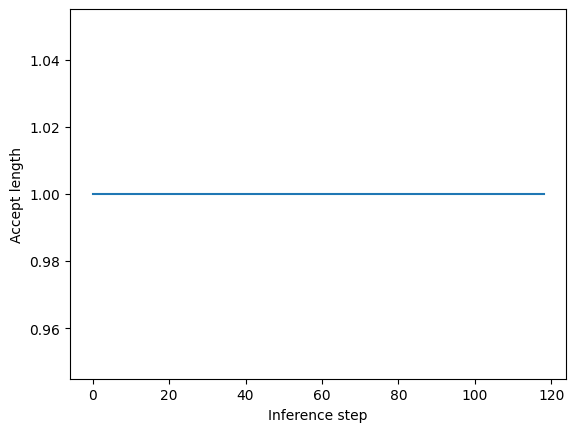

In [32]:
plt.plot(accept_lengths)
plt.xlabel('Inference step')
plt.ylabel('Accept length')
print('Avg. accept length:', np.mean(accept_lengths))

## Unleash（使爆发；发泄） the power of Medusa by Tree Attention

Only a 1.58x speedup? You might think that's underwhelming. However, remember what we implemented in the previous section was merely the list structure of Medusa heads. This means we utilized only the Top-1 prediction from each Medusa head. In this section, we will introduce the Tree Attention mechanism, which is the key to unlocking the full potential of Medusa heads. We show a tree structure of Medusa heads below.

<div align="center">
  <picture>
  <img src="../assets/medusa_choices.png" width="100%">
  </picture>
  <br>
  <div align="left" width="80%">
  <em>  We won't dive deep into how this tree was constructed. In simple terms, the tree shows us the optimized paths chosen by an algorithm that looks for the highest accuracy expectations under constraints. At every depth level, childrens from one node moving from left to right shows the top-k selections for each Medusa head. Noticeably, the Top-0 of Medusa head 1 has the most branching out, making the tree tilt more to the left. The left-heavy nature of the tree indicates that the top choices (shallower on the left) tend to have higher accuracy expectations. This suggests that the earliler (head 1 or 2) or topmost (top 1 or 2) choices are more reliable in their predictions. 
  </em>
  </div>
  <br>
</div>

Let's try the tree attention with practical example!

### Initial inference with Medusa heads

In [ ]:
with torch.inference_mode():
    new_token = 0
    input_ids = tokenizer([prompt]).input_ids
    input_len = len(input_ids[0])
    input_ids = torch.as_tensor(input_ids) #.cuda()
    model.current_length_data.zero_() # this is for rerun
    reset_medusa_mode(model)
    medusa_buffers = generate_medusa_buffers( medusa_choices, device=model.base_model.device)
    medusa_logits, logits = medusa_infer(input_ids, model, medusa_buffers["medusa_attn_mask"], past_key_values)

In [207]:
medusa_choices

[[0],
 [0, 0],
 [1],
 [0, 1],
 [2],
 [0, 0, 0],
 [1, 0],
 [0, 2],
 [3],
 [0, 3],
 [4],
 [0, 4],
 [2, 0],
 [0, 5],
 [0, 0, 1],
 [5],
 [0, 6],
 [6],
 [0, 7],
 [0, 1, 0],
 [1, 1],
 [7],
 [0, 8],
 [0, 0, 2],
 [3, 0],
 [0, 9],
 [8],
 [9],
 [1, 0, 0],
 [0, 2, 0],
 [1, 2],
 [0, 0, 3],
 [4, 0],
 [2, 1],
 [0, 0, 4],
 [0, 0, 5],
 [0, 0, 0, 0],
 [0, 1, 1],
 [0, 0, 6],
 [0, 3, 0],
 [5, 0],
 [1, 3],
 [0, 0, 7],
 [0, 0, 8],
 [0, 0, 9],
 [6, 0],
 [0, 4, 0],
 [1, 4],
 [7, 0],
 [0, 1, 2],
 [2, 0, 0],
 [3, 1],
 [2, 2],
 [8, 0],
 [0, 5, 0],
 [1, 5],
 [1, 0, 1],
 [0, 2, 1],
 [9, 0],
 [0, 6, 0],
 [0, 0, 0, 1],
 [1, 6],
 [0, 7, 0]]

In [7]:
sorted_medusa_choices = sorted(medusa_choices, key=lambda x: (len(x), x))
sorted_medusa_choices

[[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [0, 0],
 [0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [0, 5],
 [0, 6],
 [0, 7],
 [0, 8],
 [0, 9],
 [1, 0],
 [1, 1],
 [1, 2],
 [1, 3],
 [1, 4],
 [1, 5],
 [1, 6],
 [2, 0],
 [2, 1],
 [2, 2],
 [3, 0],
 [3, 1],
 [4, 0],
 [5, 0],
 [6, 0],
 [7, 0],
 [8, 0],
 [9, 0],
 [0, 0, 0],
 [0, 0, 1],
 [0, 0, 2],
 [0, 0, 3],
 [0, 0, 4],
 [0, 0, 5],
 [0, 0, 6],
 [0, 0, 7],
 [0, 0, 8],
 [0, 0, 9],
 [0, 1, 0],
 [0, 1, 1],
 [0, 1, 2],
 [0, 2, 0],
 [0, 2, 1],
 [0, 3, 0],
 [0, 4, 0],
 [0, 5, 0],
 [0, 6, 0],
 [0, 7, 0],
 [1, 0, 0],
 [1, 0, 1],
 [2, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 1]]

In [8]:
medusa_len: int = len(sorted_medusa_choices) + 1 # 共有64种medusa head组合, +1是为了base_model.cur_token
medusa_len

64

We have a function `generate_candidates` to retrieve the top-k predictions on the tree.

`tree_candidates` contains the predictions on the nodes of the tree (also include the root node which is the model's head prediction).

The `candidates` are all the paths (total 42) from the root node to the leaf nodes, padded with `<unk>` token.

In [9]:
candidates, tree_candidates = generate_candidates(
                medusa_logits,
                logits,
                medusa_buffers["tree_indices"],
                medusa_buffers["retrieve_indices"],
            )
print('Candidates shape:', candidates.shape)
print('Tree candidates shape:', tree_candidates.shape)
print('Most left 2 candidates path:', tokenizer.batch_decode(candidates[0]), tokenizer.batch_decode(candidates[1]))
print('Another candidate path:', tokenizer.batch_decode(candidates[-1]))

Candidates shape: torch.Size([42, 5])
Tree candidates shape: torch.Size([1, 64])
Most left 2 candidates path: ['the', '�', '\n', '�', '�'] ['the', '�', '\n', '�', '�']
Another candidate path: ['the', '�', '�', '<unk>', '<unk>']


### Second inference with Medusa heads

Like the previous section, we still need to verify the Medusa heads' prediction. Since we perform the greedy decoding, we set the `temperature` to **0.0** and ignore the `posterior_threshold` and `posterior_alpha` parameters. 

We have two functions, `tree_decoding` and `evaluate_posterior`.

The `tree_decoding` performs the tree-attention-based inference.

The `evaluate_posterior` performs the verification of the tree.

In [10]:
with torch.inference_mode():
    medusa_logits, logits, outputs = tree_decoding(
                model,
                tree_candidates,
                past_key_values,
                medusa_buffers["medusa_position_ids"],
                input_ids,
                medusa_buffers["retrieve_indices"],
            )
    best_candidate, accept_length = evaluate_posterior( logits, candidates, temperature = 0, posterior_threshold = 0, posterior_alpha = 0)
    print('Medusa logits shape', medusa_logits.shape)
    print('Logits shape', logits.shape)
    print('Best candidate path index:', best_candidate.item())
    print('Accept length:', accept_length.item())

Medusa logits shape torch.Size([5, 42, 5, 32000])
Logits shape torch.Size([42, 5, 32000])
Best candidate path index: 0
Accept length: 0


Let's see how the best candidate path looks like.

In [37]:
print('Retrieved input @ best candidate:', tokenizer.batch_decode(candidates[best_candidate.item()]))
print('Retrieved output @ best candidate:', tokenizer.batch_decode(logits.argmax(-1)[best_candidate.item()]))

print('Retrieved input @ another candidate:', tokenizer.batch_decode(candidates[0]))
print('Retrieved output @ another candidate:', tokenizer.batch_decode(logits.argmax(-1)[0]))


Retrieved input @ best candidate: ['the', '�', '\n', '�', '�']
Retrieved output @ best candidate: ['most', 's', '"', 's', 'led']
Retrieved input @ another candidate: ['the', '�', '\n', '�', '�']
Retrieved output @ another candidate: ['most', 's', '"', 's', 'led']


The verification is very, very similar to what we discussed in the previous section, **shift and compare**. 

Best path looks like this:
<table border="1">
    <thead>
        <tr>
            <th>Input</th>
            <td>'Once'</td>
            <td>'upon'</td>
            <td>'a'</td>
            <td>'time'</td>
            <td>'&lt;unk&gt'</td>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>Model output</th>
            <td>'upon'<br>&#9989</td>
            <td>'a'<br>&#9989</td>
            <td>'time'<br>&#9989</td>
            <td>','<br>&#x274C</td>
            <td>'char'<br>&#x274C</td>
        </tr>
    </tbody>
</table>

Another path looks like this:
<table border="1">
    <thead>
        <tr>
            <th>Input</th>
            <td>'Once'</td>
            <td>'upon'</td>
            <td>'ly'</td>
            <td>'time'</td>
            <td>'a'</td>
        </tr>
    </thead>
    <tbody>
        <tr>
            <th>Model output</th>
            <td>'upon'<br>&#9989</td>
            <td>'a'<br>&#9989</td>
            <td>'a'<br>&#x274C</td>
            <td>','<br>&#x274C</td>
            <td>'char'<br>&#x274C</td>
        </tr>
    </tbody>
</table>

The best path contains more accepted tokens, so it win the competition!

Now we will manage the KV cache (as we discussed before) and choose the correct input tokens on the path and it's medusa predictions for next tree.

In [26]:
input_ids, logits, medusa_logits, new_token = update_inference_inputs(
                input_ids,
                candidates,
                best_candidate,
                accept_length,
                medusa_buffers["retrieve_indices"],
                outputs,
                logits,
                medusa_logits,
                new_token,
                past_key_values_data,
                current_length_data,
            )
print('Decode:', tokenizer.batch_decode(input_ids[:,input_len:]))

Decode: ['Once upon a time']


### It's time to put all the things together!

Below is the whole process of the tree attention inference. The acceleration ratio is boosted from ~1.6X to ~2.4X!

In [ ]:
accept_lengths_tree = []

with torch.inference_mode():
    new_token = 0
    input_ids = tokenizer([prompt]).input_ids
    input_len = len(input_ids[0])
    input_ids = torch.as_tensor(input_ids).cuda()
    model.current_length_data.zero_() # this is for rerun
    reset_medusa_mode(model)
    medusa_buffers = generate_medusa_buffers(
                medusa_choices, device=model.base_model.device
            )
    medusa_logits, logits = medusa_infer(
            input_ids, model, medusa_buffers["medusa_attn_mask"], past_key_values
        )
    cur_length = input_len + 1
    accept_lengths_tree.append(1)
    
    for i in range(1024):
        candidates, tree_candidates = generate_candidates(
                medusa_logits,
                logits,
                medusa_buffers["tree_indices"],
                medusa_buffers["retrieve_indices"],
            )
        medusa_logits, logits, outputs = tree_decoding(
                model,
                tree_candidates,
                past_key_values,
                medusa_buffers["medusa_position_ids"],
                input_ids,
                medusa_buffers["retrieve_indices"],
            )
        best_candidate, accept_length = evaluate_posterior(
                logits, candidates, temperature = 0, posterior_threshold = 0, posterior_alpha = 0
            )
        input_ids, logits, medusa_logits, new_token = update_inference_inputs(
                input_ids,
                candidates,
                best_candidate,
                accept_length,
                medusa_buffers["retrieve_indices"],
                outputs,
                logits,
                medusa_logits,
                new_token,
                past_key_values_data,
                current_length_data,
            )
        
        accept_length_tree = input_ids.shape[1] - cur_length
        cur_length = accept_length_tree + cur_length
        accept_lengths_tree.append(accept_length_tree)
        if model.tokenizer.eos_token_id in input_ids[0, input_len:]:
            break
print('Decode:', tokenizer.batch_decode(input_ids[:,input_len:]))

Decode: ['Once upon a time, in a small village nestled in the Andes mountains, there lived a charming llama named Luna. Luna was known for her kind heart and her love of coffee. She would often spend her afternoons sipping on a steaming cup of joe at the local café, chatting with the villagers and enjoying the warmth of the sun on her back.\n\nOne day, as Luna was grazing on some fresh grass, she noticed that her hair was starting to grow longer and thicker. At first, she didn\'t think much of it, but as the days went on, her hair continued to grow and change. It became thick and wiry, with sharp spikes protruding from it.\n\nLuna was confused and a little scared by her new appearance. She had always been a gentle creature, and now she looked like a monster. She knew that she couldn\'t stay in the village anymore, so she set off on a journey to find a new home.\n\nAs she wandered through the mountains, Luna stumbled upon a beautiful clearing. In the center of the clearing stood a small

Avg. accept tree length: 2.4424242424242424
Avg. accept list length: 1.578125


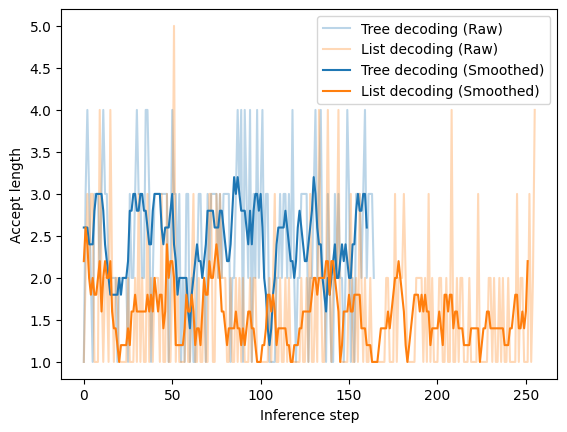

In [ ]:
# 均值滤波
def moving_average(data, window_size=5):
    # np.convolve为数字卷积, 即sum_{i}{a[i]*v[n-i]}
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Unsmoothed plots with transparency
plt.plot(accept_lengths_tree, label='Tree decoding (Raw)', alpha=0.3)
plt.plot(accept_lengths, label='List decoding (Raw)', alpha=0.3)

# Smoothed plots
window_size = 5  # You can adjust this as needed
plt.plot(moving_average(accept_lengths_tree, window_size), label='Tree decoding (Smoothed)', color='tab:blue')
plt.plot(moving_average(accept_lengths, window_size), label='List decoding (Smoothed)', color='tab:orange')

plt.xlabel('Inference step')
plt.ylabel('Accept length')
plt.legend()

print('Avg. accept tree length:', np.mean(accept_lengths_tree))
print('Avg. accept list length:', np.mean(accept_lengths))

plt.show()
